# 04 — CNN + BatchNorm + Dropout + Data Augmentation on CIFAR-10

**Project:** Progressive CNN Classifier Study
**Stage:** 4 of 6 — Adding Data Augmentation

### Goal
Take the winning architecture from Notebook 03 (BatchNorm + Dropout, 72.50% test accuracy) and add **Data Augmentation** — randomly transforming training images on the fly so the model effectively never sees the exact same image twice.

### Scoreboard so far
| Notebook | Technique | Test Accuracy | Test Loss |
|---|---|---|---|
| 01 | Baseline | 0.7166 | 0.8821 |
| 02 | + BatchNorm | 0.6807 | 1.5024 |
| 03 | + BatchNorm + Dropout | 0.7250 | 0.7805 |
| 04 (this one) | + Data Augmentation | 0.6359 | 1.0204 |

### What is Data Augmentation?
Instead of feeding the network the same fixed 50,000 training images every epoch, we apply random transformations — flips, rotations, shifts, zooms — each epoch. This:
- **Artificially expands the training set** — the model sees countless variations of each image, not the same exact pixels repeatedly.
- **Reduces overfitting further** — harder for the network to memorize specific images if they look slightly different every time.
- **Improves robustness** — the model learns to recognize a "cat" whether it's flipped, slightly rotated, or off-center, which better reflects real-world image variation.

This is a *data-level* regularizer, unlike BatchNorm (architecture-level) and Dropout (training-level) — a genuinely different tool in the toolbox.

### What this notebook covers
- Using Keras preprocessing layers to build an augmentation pipeline
- Visualizing what augmented images actually look like
- Applying augmentation only to training data (never to validation/test — that would corrupt evaluation)
- Comparing results against Notebook 03

## 1. Imports

In [3]:
import os
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.21.0
GPU available: []


## 2. Load and Preprocess CIFAR-10

Same as always — normalize pixels to [0, 1]. Augmentation gets added as *layers inside the model* in the next step, not here, so this cell stays identical to Notebooks 01-03.

In [4]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

class_names = ["airplane", "automobile", "bird", "cat", "deer",
               "dog", "frog", "horse", "ship", "truck"]

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 3. Build the Augmentation Pipeline

Using Keras preprocessing layers (`tf.keras.layers`) instead of the older `ImageDataGenerator` — these run as part of the model graph and are the modern recommended approach.

- `RandomFlip("horizontal")` — flips images left-right (a horizontally flipped cat is still a cat; a vertically flipped one looks wrong, so we skip vertical flip).
- `RandomRotation(0.1)` — rotates up to ~10% of 360° (~36°) in either direction.
- `RandomZoom(0.1)` — zooms in/out by up to 10%.
- `RandomTranslation(0.1, 0.1)` — shifts the image up to 10% horizontally/vertically, simulating off-center framing.

These layers are **only active during training** (`training=True`) — Keras automatically disables them during evaluation/inference, so validation and test data pass through unmodified.

In [5]:
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1),
], name="data_augmentation")

### Visualize Augmented Images

Always sanity-check augmentation visually before training — it's easy to accidentally set parameters so extreme that images become unrecognizable, which would hurt rather than help.

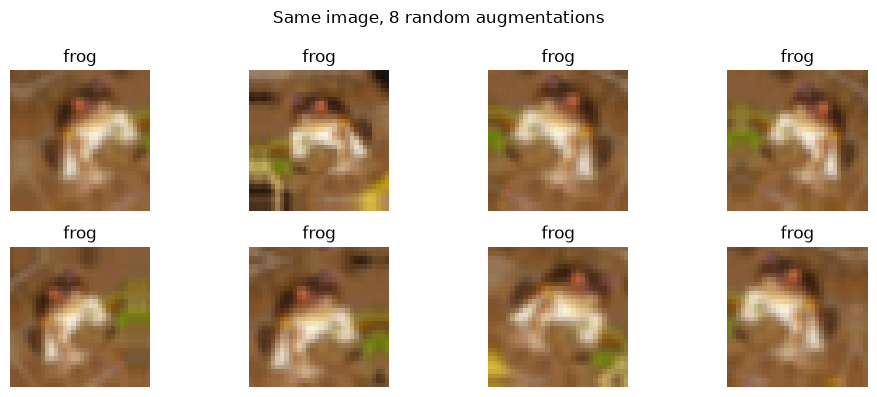

In [6]:
plt.figure(figsize=(10, 4))
sample_image = tf.expand_dims(x_train[0], 0)

for i in range(8):
    augmented = data_augmentation(sample_image, training=True)
    plt.subplot(2, 4, i + 1)
    plt.imshow(augmented[0])
    plt.title(class_names[y_train[0][0]])
    plt.axis("off")

plt.suptitle("Same image, 8 random augmentations")
plt.tight_layout()
plt.show()

## 4. Build the Full Model

**Same architecture as Notebook 03** (BatchNorm + Dropout), with the augmentation pipeline added as the very first layer. Since augmentation layers are inert at inference time, this single model works correctly for both training and evaluation — no separate pipelines needed.

In [7]:
model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    data_augmentation,

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(10, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 4, 4, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 123,210 (481.29 KB)

 Trainable params: 122,890 (480.04 KB)

 Non-trainable params: 320 (1.25 KB)

## 5. Compile

Same optimizer, loss, and metric as every previous notebook.

In [8]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## 6. Train

Same 15 epochs, batch size 64. Note: augmentation makes each epoch slightly harder to fit (by design), so don't be surprised if early-epoch accuracy looks a bit lower than Notebook 03 — the real test is where validation accuracy ends up.

In [9]:
history = model.fit(
    x_train, y_train,
    epochs=15,
    batch_size=64,
    validation_data=(x_test, y_test)
)

Epoch 1/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.2853 - loss: 2.0485 - val_accuracy: 0.4023 - val_loss: 1.6322
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.3869 - loss: 1.6821 - val_accuracy: 0.4410 - val_loss: 1.5594
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.4311 - loss: 1.5825 - val_accuracy: 0.5021 - val_loss: 1.3780
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.4576 - loss: 1.5171 - val_accuracy: 0.4455 - val_loss: 1.5717
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.4743 - loss: 1.4688 - val_accuracy: 0.5162 - val_loss: 1.4445
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.4894 - loss: 1.4300 - val_accuracy: 0.5487 - val_loss: 1.2577
Epoch 7/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.5032 - loss: 1.3958 - val_accuracy: 0.5267 - val_loss: 1.2981
Epoch 8/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.5101 - loss: 1.3784 - 

## 7. Save the Model

In [10]:
os.makedirs("models", exist_ok=True)
os.makedirs("results", exist_ok=True)

model.save("models/augmentation_cnn.h5")
print("Model saved to models/augmentation_cnn.h5")

Model saved to models/augmentation_cnn.h5


## 8. Visualize Training Curves

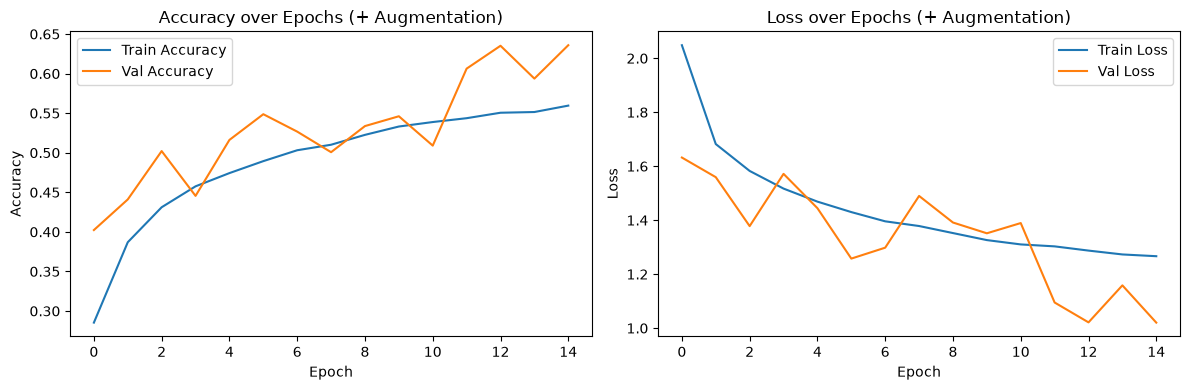

In [11]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.title("Accuracy over Epochs (+ Augmentation)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Loss over Epochs (+ Augmentation)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.savefig("results/augmentation_cnn_curves.png")
plt.show()

## 9. Final Evaluation

In [12]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Final Test Accuracy: {test_acc:.4f}")
print(f"Final Test Loss: {test_loss:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6359 - loss: 1.0204
Final Test Accuracy: 0.6359
Final Test Loss: 1.0204


## 10. Direct Comparison vs. Previous Stages

In [13]:
results_table = [
    ("Baseline (01)", 0.7166, 0.8821),
    ("BatchNorm (02)", 0.6807, 1.5024),
    ("BatchNorm + Dropout (03)", 0.7250, 0.7805),
    ("+ Data Augmentation (04)", test_acc, test_loss),
]

print(f"{'Model':<28}{'Test Accuracy':<18}{'Test Loss':<12}")
for name, acc, loss in results_table:
    print(f"{name:<28}{acc:<18.4f}{loss:<12.4f}")

print(f"\nAccuracy change vs Notebook 03: {test_acc - 0.7250:+.4f}")

Model                       Test Accuracy     Test Loss   
Baseline (01)               0.7166            0.8821      
BatchNorm (02)              0.6807            1.5024      
BatchNorm + Dropout (03)    0.7250            0.7805      
+ Data Augmentation (04)    0.6359            1.0204      

Accuracy change vs Notebook 03: -0.0891


## Summary & Next Steps

| Notebook | Technique Added | Test Accuracy |
|---|---|---|
| 01 | None (baseline) | 0.7166 |
| 02 | + Batch Normalization | 0.6807 |
| 03 | + Dropout | 0.7250 |
| 04 | + Data Augmentation | 0.6359 (35-epoch follow-up in 04b: 0.6680) |
| 05 | + LR Scheduling | 0.7407 |
| 06 | Transfer Learning (MobileNetV2) | 0.8928 |

**Interpretation tip for your report:** with only 15 epochs, augmentation sometimes shows a smaller (or even negative) benefit purely because the model needs *more* epochs to fully exploit the expanded effective dataset — it's learning from "harder", more varied examples each epoch. If accuracy is similar or slightly lower than Notebook 03 but train/val curves are tracking even closer together (or train accuracy is now *below* val accuracy, its own kind of signal), that's still meaningful and worth discussing rather than dismissing as "no improvement."

**Next:** proceed to `05_lr_scheduling.ipynb`, where we add a learning rate schedule/callback so the optimizer takes smaller, more precise steps as training progresses.